In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import torch

# Increase the font scale for seaborn
sns.set(font_scale=1.5)  # Adjust this value to increase or decrease font size
sns.set_style("white")  # Set the background to white

# Step 1: Use glob to find all files matching the pattern '*/final_results.csv'
main_path = "/gpfs/commons/home/kisaev/Leaflet-analysis/simulations/testing"
file_paths = glob.glob(os.path.join(main_path, '*/final_results.csv'))

# Check if file paths are found correctly
print(f"Found {len(file_paths)} files.")

# Step 2: Read all CSV files into a list of dataframes
dataframes = [pd.read_csv(file) for file in file_paths]

# Step 3: Concatenate all dataframes into a single dataframe
combined_df = pd.concat(dataframes, ignore_index=True)

Found 105 files.


In [2]:
combined_df.head()

,proportion_negative,K,use_global_prior,input_conc,learning_rate,avg_corr,median_corr,min_corr,correlation_diff,auc_score,optimal_threshold,accuracy,precision,recall,false_positives,false_negatives,silhouette_avg,cell_type_column,silhouette_NMF,input_conc.1
0,0.9,17,True,inf,0.05,0.279045,0.274486,0.236040,0.513211,0.991484,2.513304,0.945499,0.631325,0.992424,153,2,0.102361,cell_type,0.013542,inf
1,0.1,17,True,inf,0.05,0.629737,0.643011,0.504882,0.534724,0.845604,5.126162,0.867792,0.932726,0.906751,155,221,0.487893,cell_type,0.097267,inf
2,0.9,17,True,48.13409,0.05,0.424050,0.418656,0.321286,0.504593,0.982773,0.979989,0.921941,0.543933,0.984848,218,4,0.330566,cell_type,0.032149,48.13409
3,0.9,17,True,68.73105,0.05,0.529885,0.516694,0.379114,0.500712,0.978032,0.798505,0.914205,0.520408,0.965909,235,9,0.334407,cell_type,0.016694,68.73105
4,0.1,2,False,inf,0.05,0.962765,0.960551,0.942775,0.845406,0.908654,13.049438,0.852510,0.882997,0.874429,203,220,0.996140,NaN,0.330849,inf


In [3]:
# Remove the extra input_conc column
combined_df = combined_df.drop(columns=["input_conc.1"])

In [4]:
# Create new likelihood column based on input_conc
combined_df["likelihood"] = combined_df["input_conc"].apply(lambda x: "binomial" if x == float('inf') else "beta0-binomial")

In [5]:
combined_df['combined_prior_input'] = combined_df['use_global_prior'].astype(str) + '-' + combined_df['likelihood']

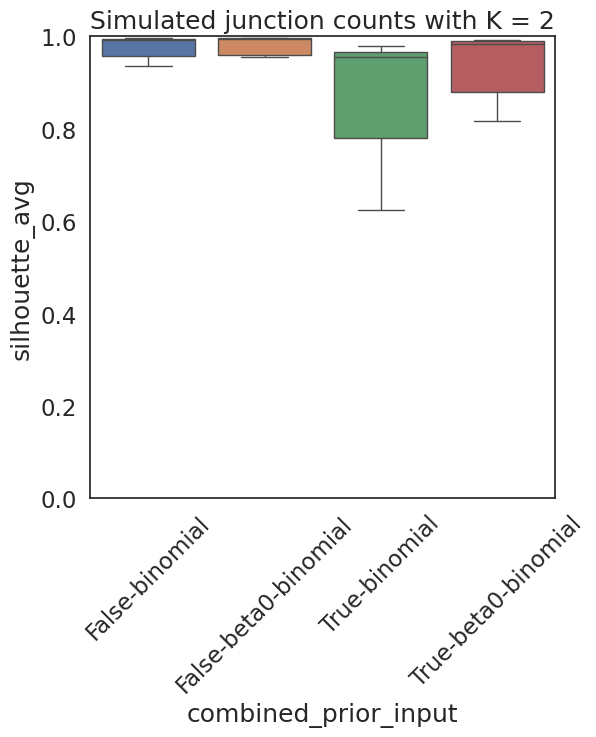

In [6]:
k2 = combined_df[combined_df["K"] == 2]
plt.figure(figsize=(6,6))
sns.boxplot(x='combined_prior_input', y='silhouette_avg', hue='combined_prior_input', data=k2)
plt.ylim(0, 1)
plt.title("Simulated junction counts with K = 2")
plt.xticks(rotation=45)  # Rotates the x-axis labels by 45 degrees
plt.show()

Text(0.5, 1.0, 'Simulated junction counts with K = 2')

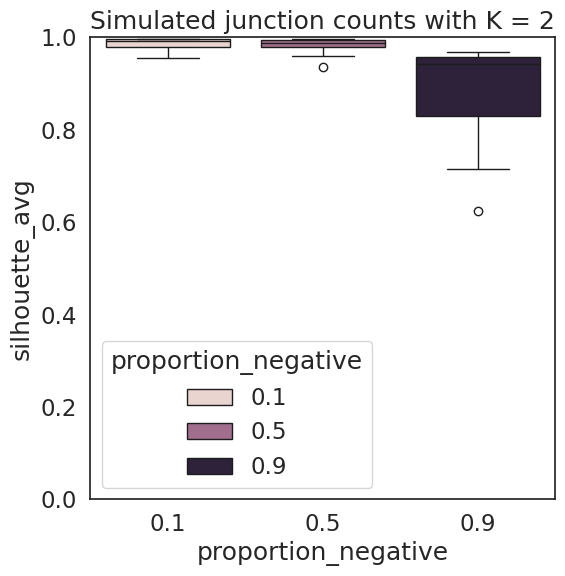

In [7]:
# plot silouette average across different K values 
plt.figure(figsize=(6,6))
sns.boxplot(x='proportion_negative', y='silhouette_avg', hue='proportion_negative', data=k2)
plt.ylim(0, 1)
plt.title("Simulated junction counts with K = 2")

Text(0.5, 1.0, 'Simulated junction counts with K = 17 \n(based on real cell type labels)')

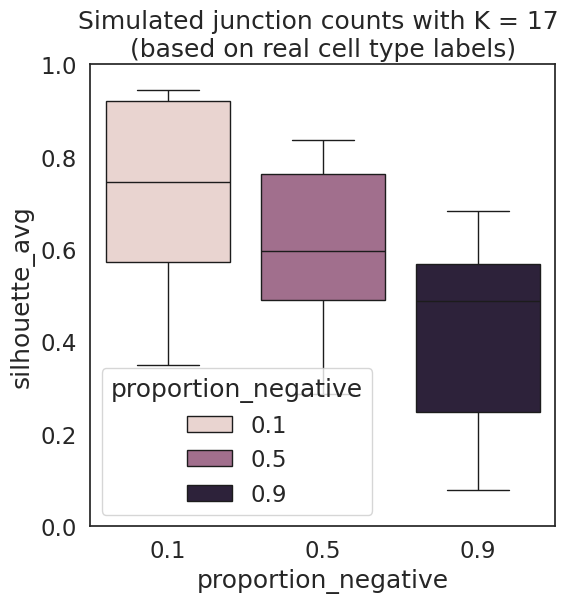

In [8]:
# plot silouette average across different K values 
k17 = combined_df[combined_df["K"] == 17]
plt.figure(figsize=(6,6))
sns.boxplot(x='proportion_negative', y='silhouette_avg', hue='proportion_negative', data=k17)
plt.ylim(0, 1)
plt.title("Simulated junction counts with K = 17 \n(based on real cell type labels)")

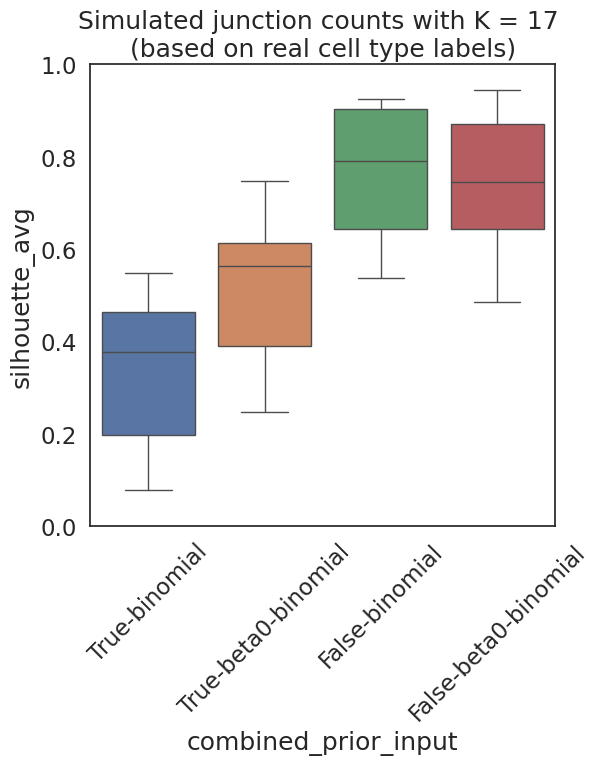

In [9]:
plt.figure(figsize=(6,6))
sns.boxplot(x='combined_prior_input', y='silhouette_avg', hue='combined_prior_input', data=k17)
plt.ylim(0, 1)
plt.title("Simulated junction counts with K = 17 \n(based on real cell type labels)")
plt.xticks(rotation=45)  # Rotates the x-axis labels by 45 degrees
plt.show()

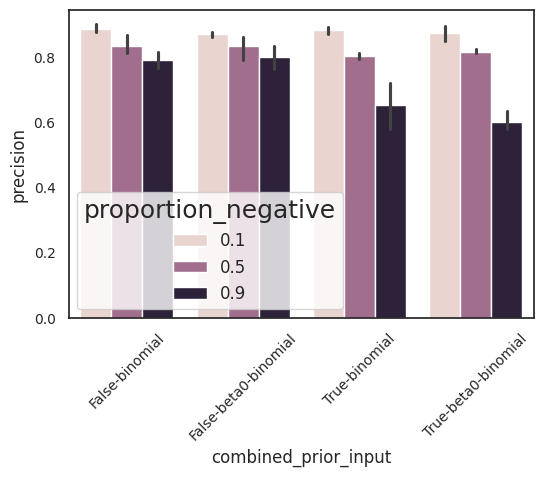

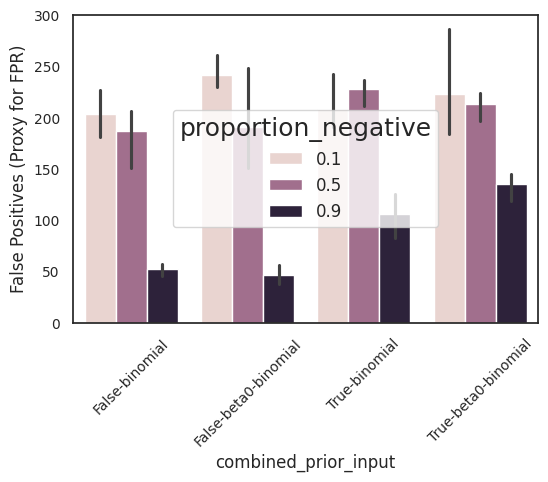

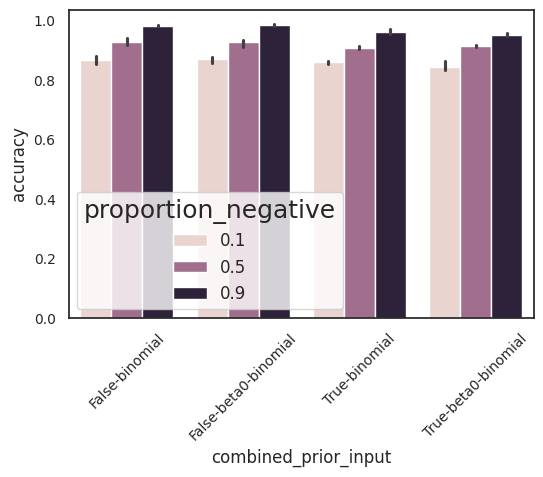

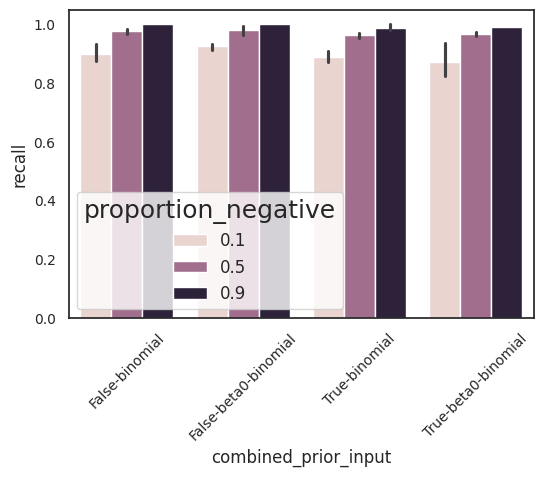

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set font size for all elements
plt.rcParams.update({
    'axes.titlesize': 14,    # Title font size
    'axes.labelsize': 12,    # Axis label font size
    'xtick.labelsize': 10,   # X-axis tick label font size
    'ytick.labelsize': 10,   # Y-axis tick label font size
    'legend.fontsize': 12    # Legend font size
})

# Step 1: Filter the dataframe to include only K=2
df_k2 = combined_df[combined_df['K'] == 2]

# Precision 
plt.figure(figsize=(6, 4))  # Adjust figure size to make it smaller
sns.barplot(x='combined_prior_input', y='precision', hue='proportion_negative', data=df_k2)
plt.xticks(rotation=45)  # Rotate x-axis tick labels
plt.show()

# False Positive Rate (using false positives directly)
plt.figure(figsize=(6, 4))
sns.barplot(x='combined_prior_input', y='false_positives', hue='proportion_negative', data=df_k2)
plt.ylabel('False Positives (Proxy for FPR)')
plt.xticks(rotation=45)  # Rotate x-axis tick labels
plt.show()

# Accuracy
plt.figure(figsize=(6, 4))
sns.barplot(x='combined_prior_input', y='accuracy', hue='proportion_negative', data=df_k2)
plt.xticks(rotation=45)  # Rotate x-axis tick labels
plt.show()

# Recall 
plt.figure(figsize=(6, 4))
sns.barplot(x='combined_prior_input', y='recall', hue='proportion_negative', data=df_k2)
plt.xticks(rotation=45)  # Rotate x-axis tick labels
plt.show()


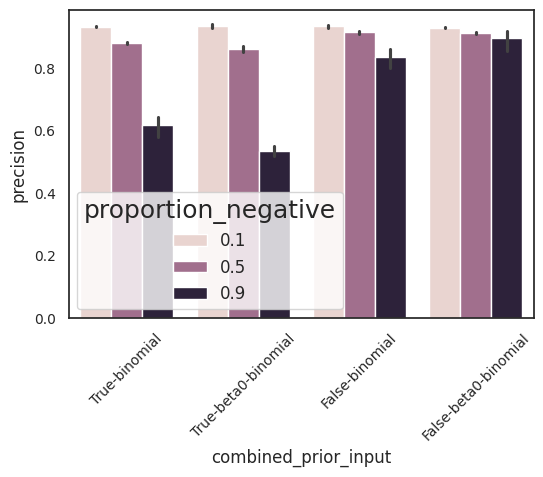

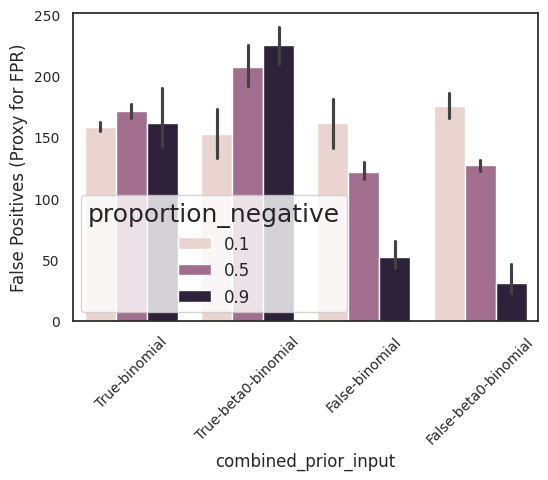

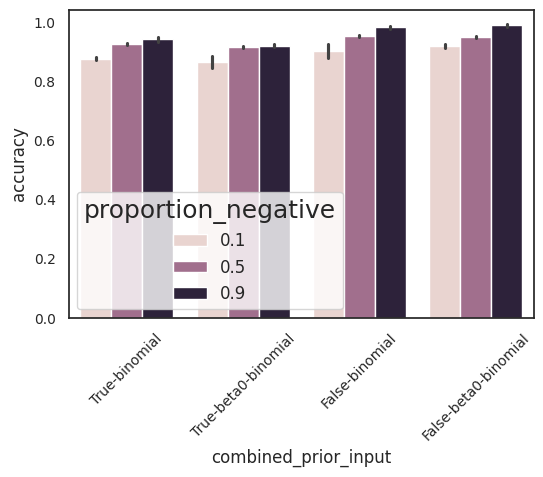

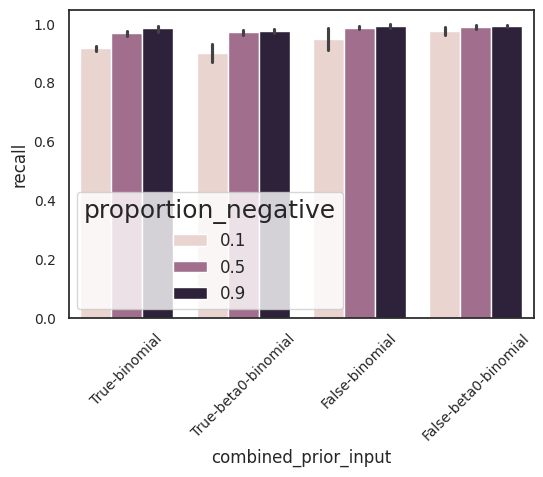

In [11]:
# Step 1: Filter the dataframe to include only K=17
df_k17 = combined_df[combined_df['K'] == 17]

# Precision 
plt.figure(figsize=(6, 4))
sns.barplot(x='combined_prior_input', y='precision', hue='proportion_negative', data=df_k17)
plt.xticks(rotation=45)  # Rotate x-axis tick labels
plt.show()

# False Positive Rate (using false positives directly)
plt.figure(figsize=(6, 4))
sns.barplot(x='combined_prior_input', y='false_positives', hue='proportion_negative', data=df_k17)
plt.ylabel('False Positives (Proxy for FPR)')
plt.xticks(rotation=45)  # Rotate x-axis tick labels
plt.show()

# Accuracy
plt.figure(figsize=(6, 4))
sns.barplot(x='combined_prior_input', y='accuracy', hue='proportion_negative', data=df_k17)
plt.xticks(rotation=45)  # Rotate x-axis tick labels
plt.show()

# Recall 
plt.figure(figsize=(6, 4))
sns.barplot(x='combined_prior_input', y='recall', hue='proportion_negative', data=df_k17)
plt.xticks(rotation=45)  # Rotate x-axis tick labels
plt.show()


In [12]:
# Across different Ks, combined_prior_input and prop negative, let's summarize avg_corr across inits, silouette score

# Step 1: Group the dataframe by K, combined_prior_input, and proportion_negative
grouped_summary = combined_df.groupby(['K', 'combined_prior_input', 'proportion_negative']).agg(
    avg_corr_mean=('avg_corr', 'mean'),
    silhouette_avg_mean=('silhouette_avg', 'mean')
).reset_index()

/scratch/ipykernel_44182/7815854.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='K', y='silhouette_avg_mean', hue='combined_prior_input', data=grouped_0_5, ci=None)


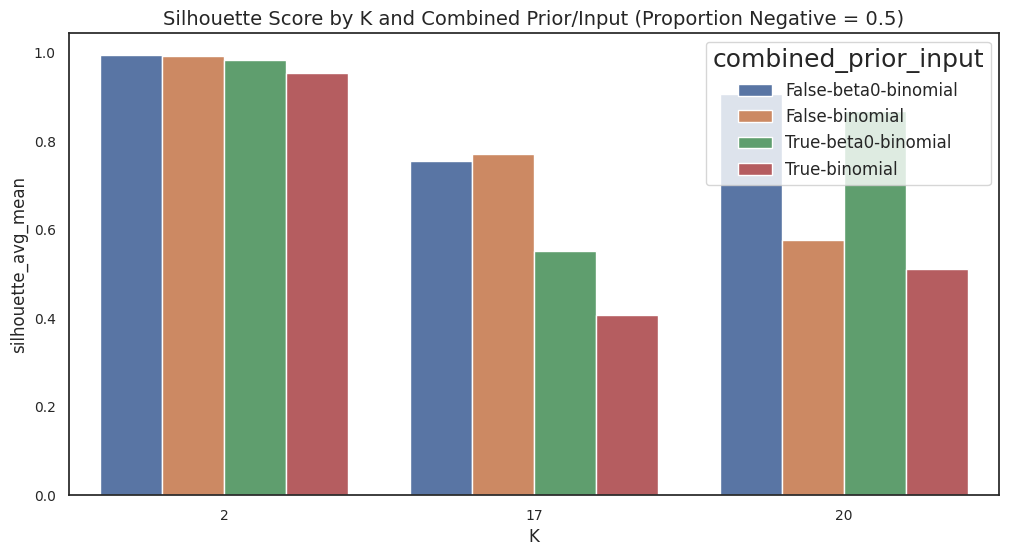

/scratch/ipykernel_44182/7815854.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='K', y='silhouette_avg_mean', hue='combined_prior_input', data=grouped_0_99, ci=None)


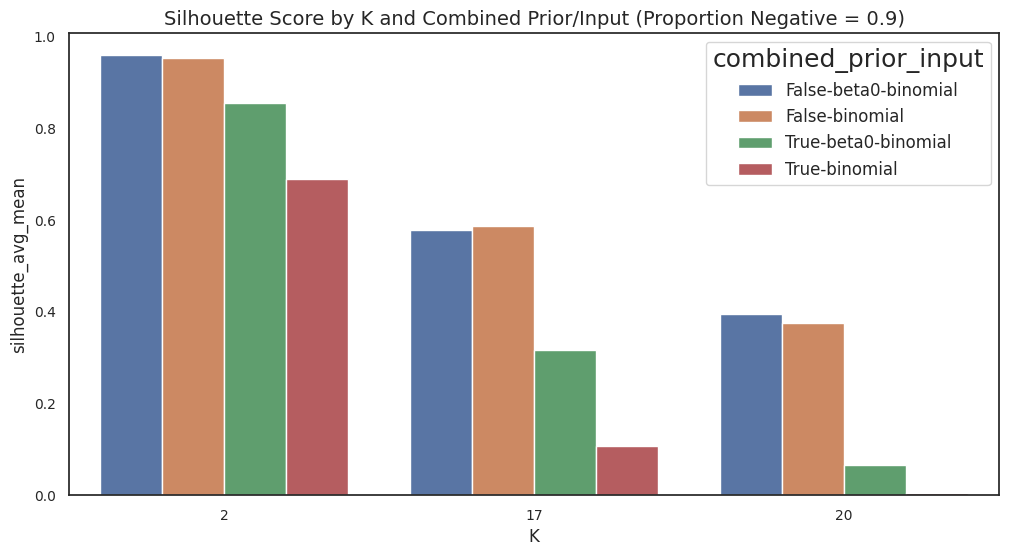

In [13]:
# Filter for proportion_negative = 0.5
grouped_0_5 = grouped_summary[grouped_summary['proportion_negative'] == 0.5]

# Filter for proportion_negative = 0.99
grouped_0_99 = grouped_summary[grouped_summary['proportion_negative'] == 0.9]

# Plot for proportion_negative = 0.5
plt.figure(figsize=(12, 6))
sns.barplot(x='K', y='silhouette_avg_mean', hue='combined_prior_input', data=grouped_0_5, ci=None)
plt.title('Silhouette Score by K and Combined Prior/Input (Proportion Negative = 0.5)')
plt.show()

# Plot for proportion_negative = 0.99
plt.figure(figsize=(12, 6))
sns.barplot(x='K', y='silhouette_avg_mean', hue='combined_prior_input', data=grouped_0_99, ci=None)
plt.title('Silhouette Score by K and Combined Prior/Input (Proportion Negative = 0.9)')
plt.show()


/scratch/ipykernel_44182/3161220735.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='K', y='avg_corr_mean', hue='combined_prior_input', data=grouped_0_5, ci=None)


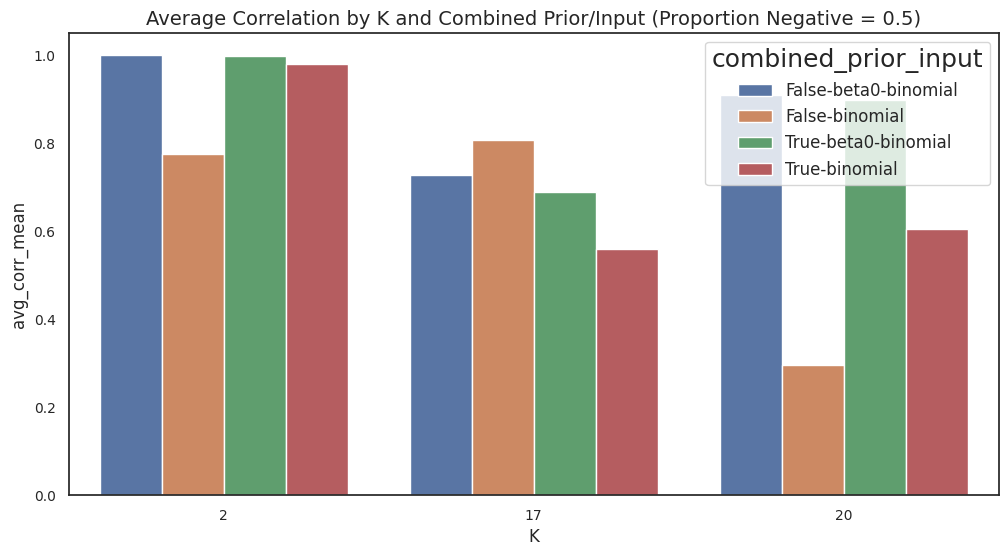

/scratch/ipykernel_44182/3161220735.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='K', y='avg_corr_mean', hue='combined_prior_input', data=grouped_0_99, ci=None)


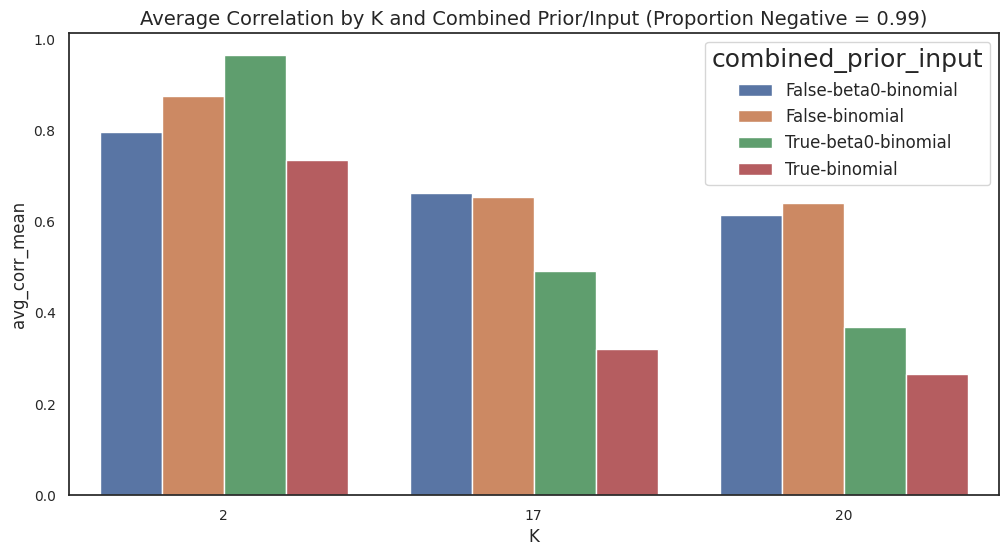

In [14]:
# Plot for proportion_negative = 0.5 (avg_corr_mean)
plt.figure(figsize=(12, 6))
sns.barplot(x='K', y='avg_corr_mean', hue='combined_prior_input', data=grouped_0_5, ci=None)
plt.title('Average Correlation by K and Combined Prior/Input (Proportion Negative = 0.5)')
plt.show()

# Plot for proportion_negative = 0.99 (avg_corr_mean)
plt.figure(figsize=(12, 6))
sns.barplot(x='K', y='avg_corr_mean', hue='combined_prior_input', data=grouped_0_99, ci=None)
plt.title('Average Correlation by K and Combined Prior/Input (Proportion Negative = 0.99)')
plt.show()


### Add precision recall plots to the main analysis...